In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])


In [3]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


In [6]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Kaiming init for proper gradient flow
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=0.01)
        self.bias        = nn.Parameter(torch.zeros(out_features))
        # Gate scores init slightly positive → gates start near 0.7 (open)
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features) * 0.5)

    def forward(self, x):
        gates_soft = torch.sigmoid(self.gate_scores)          # [0,1] soft
        gates_hard = (gates_soft > 0.5).float()               # binary hard
        # Straight-Through Estimator: hard forward, soft backward
        gates = gates_hard - gates_soft.detach() + gates_soft
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores)

    def sparsity_loss(self):
        # MEAN not SUM — prevents loss explosion
        return torch.sigmoid(self.gate_scores).mean()

In [7]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = PrunableLinear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = PrunableLinear(256, 10)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x = self.drop(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)

    def get_prunable_layers(self):
        return [self.fc1, self.fc2, self.fc3, self.fc4]

In [8]:
LAYER_LAMBDA_SCALE = [0.5, 0.8, 1.2, 2.0]

def compute_sparsity_loss(model):
    loss = 0.0
    for i, layer in enumerate(model.get_prunable_layers()):
        loss += LAYER_LAMBDA_SCALE[i] * layer.sparsity_loss()
    return loss / len(model.get_prunable_layers())

In [9]:
def compute_sparsity_percent(model, threshold=0.5):
    total, pruned = 0, 0
    for layer in model.get_prunable_layers():
        g = layer.get_gates()
        total  += g.numel()
        pruned += (g < threshold).sum().item()
    return 100.0 * pruned / total

In [10]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total

In [11]:
def train_model(lambda_max, epochs=20, warmup=3, ramp=8, seed=42):
    torch.manual_seed(seed)
    model = SelfPruningNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        # Adaptive lambda: 0 during warmup, then ramp up
        if epoch < warmup:
            lam = 0.0
        else:
            lam = lambda_max * min(1.0, (epoch - warmup) / ramp)

        total_ce, total_sp = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out     = model(imgs)
            ce_loss = criterion(out, labels)
            sp_loss = compute_sparsity_loss(model)
            loss    = ce_loss + lam * sp_loss
            loss.backward()
            # Gradient clipping — prevents explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_ce += ce_loss.item()
            total_sp += sp_loss.item()

        scheduler.step()
        acc      = evaluate(model)
        sparsity = compute_sparsity_percent(model)
        print(f"  Epoch {epoch+1:2d} | λ={lam:.4f} | CE={total_ce/len(train_loader):.3f} | "
              f"Sparsity={sparsity:.1f}% | Acc={acc:.1f}%")

    final_acc      = evaluate(model)
    final_sparsity = compute_sparsity_percent(model)
    return model, final_acc, final_sparsity

In [12]:
lambda_values = [0.01, 0.1, 1.0]   # low / medium / high
results = {}

for lam in lambda_values:
    print(f"\n{'='*50}")
    print(f"Training with λ_max = {lam}")
    print('='*50)
    model, acc, sparsity = train_model(lambda_max=lam, epochs=20)
    results[lam] = {"accuracy": acc, "sparsity": sparsity, "model": model}
    print(f"\n λ={lam} → Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")


Training with λ_max = 0.01
  Epoch  1 | λ=0.0000 | CE=1.964 | Sparsity=0.0% | Acc=41.3%
  Epoch  2 | λ=0.0000 | CE=1.737 | Sparsity=0.0% | Acc=44.3%
  Epoch  3 | λ=0.0000 | CE=1.657 | Sparsity=0.0% | Acc=45.9%
  Epoch  4 | λ=0.0000 | CE=1.650 | Sparsity=16.5% | Acc=45.1%
  Epoch  5 | λ=0.0013 | CE=1.663 | Sparsity=58.6% | Acc=46.6%
  Epoch  6 | λ=0.0025 | CE=1.652 | Sparsity=63.0% | Acc=44.6%
  Epoch  7 | λ=0.0037 | CE=1.636 | Sparsity=64.0% | Acc=45.1%
  Epoch  8 | λ=0.0050 | CE=1.627 | Sparsity=64.4% | Acc=47.0%
  Epoch  9 | λ=0.0063 | CE=1.617 | Sparsity=64.1% | Acc=46.2%
  Epoch 10 | λ=0.0075 | CE=1.602 | Sparsity=63.7% | Acc=47.6%
  Epoch 11 | λ=0.0088 | CE=1.585 | Sparsity=63.6% | Acc=48.1%
  Epoch 12 | λ=0.0100 | CE=1.570 | Sparsity=63.4% | Acc=49.0%
  Epoch 13 | λ=0.0100 | CE=1.546 | Sparsity=63.4% | Acc=48.8%
  Epoch 14 | λ=0.0100 | CE=1.531 | Sparsity=63.4% | Acc=50.2%
  Epoch 15 | λ=0.0100 | CE=1.506 | Sparsity=63.5% | Acc=50.1%
  Epoch 16 | λ=0.0100 | CE=1.491 | Sparsity=6

In [13]:
print("\n\n RESULTS SUMMARY")
print(f"{'Lambda':<12} {'Test Accuracy':>15} {'Sparsity Level':>16}")
print("-" * 45)
for lam in lambda_values:
    r = results[lam]
    print(f"{lam:<12} {r['accuracy']:>14.2f}% {r['sparsity']:>15.2f}%")



 RESULTS SUMMARY
Lambda         Test Accuracy   Sparsity Level
---------------------------------------------
0.01                  54.58%           64.06%
0.1                   54.84%           78.66%
1.0                   54.90%           91.73%


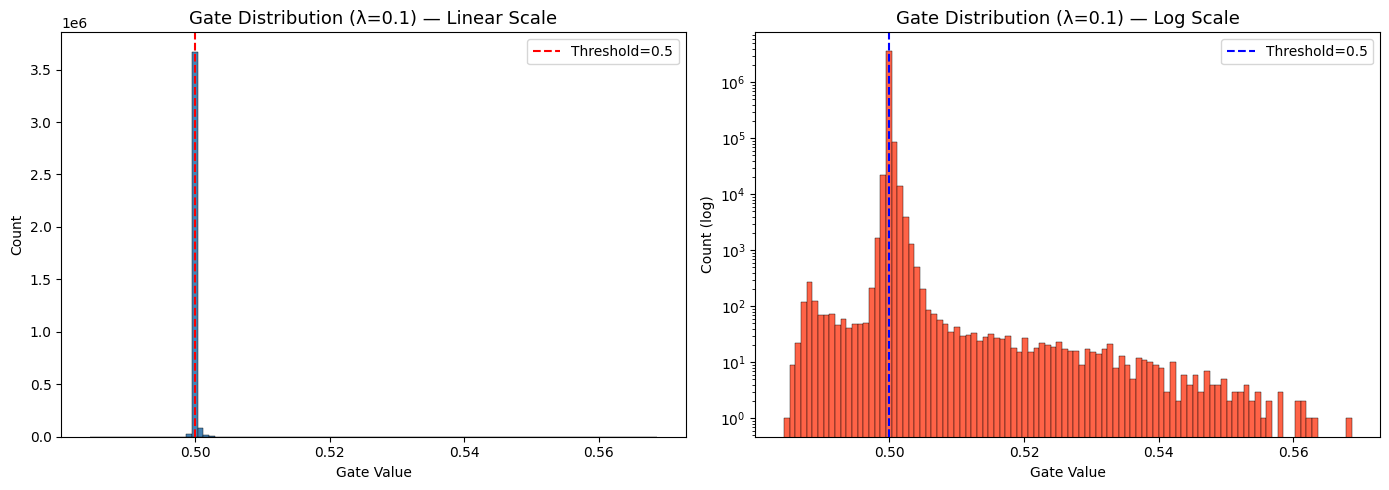


 Plot saved as gate_distribution.png


In [15]:
best_model = results[0.1]["model"]
all_gates = []
for layer in best_model.get_prunable_layers():
    all_gates.append(layer.get_gates().cpu().numpy().flatten())
all_gates = np.concatenate(all_gates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(all_gates, bins=100, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_title("Gate Distribution (λ=0.1) — Linear Scale", fontsize=13)
axes[0].set_xlabel("Gate Value")
axes[0].set_ylabel("Count")
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold=0.5')
axes[0].legend()

# Log scale — shows spike at 0 clearly
axes[1].hist(all_gates, bins=100, color='tomato', edgecolor='k', linewidth=0.3, log=True)
axes[1].set_title("Gate Distribution (λ=0.1) — Log Scale", fontsize=13)
axes[1].set_xlabel("Gate Value")
axes[1].set_ylabel("Count (log)")
axes[1].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
axes[1].legend()

plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150)
plt.show()
print("\n Plot saved as gate_distribution.png")